# Getting price for reference items

I'm done entering all my receipts. Each expense is matched with a product, which is matched with a reference item. The reference item is the non-gluten-free product that we calculate the price difference with. 

Things we'll need for each reference item:
- Price
- Weight
- URL
- Screenshot (as proof)
- Time stamp of scrape

After the initial attempt to search and save scraping: 
- Walmart.ca is difficult to scrape, I'll try another website
- Instead of the reference item name, I'll add actual product names to simplify search

Todo db changes: 
- Need a table for scrapes with url, info, timestamp
- Reference item: keep name, but remove info, link to latest product scrape

In [1]:
%pip install -q pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

## Load list of product names

In [4]:
df_mapping = pd.read_csv('reference_products_mapping.csv')
df_mapping.head()

,id,name,product_name
0,1,BBQ Sauce,Kraft BBQ Sauce
1,2,Beans,Heinz Baked Beans
2,3,Bouillon cubes,Knorr Chicken Bouillon
3,4,Candy,Maynards Swedish Berries
4,5,Cereal,Kellogg's Corn Flakes


## Get the goods

In [5]:
%pip install -q \
    requests \
    bs4 \
    fake_useragent

Note: you may need to restart the kernel to use updated packages.


### First: find product (cheapest), get product page URL (screenshot)

In [49]:
# cleaner version

import json
import requests
from bs4 import BeautifulSoup

# https://www.foodbasics.ca/search?sortOrder=price-asc&filter={query}
# https://www.walmart.ca/en/search?q={query}&sort=price_low

def scrape_search(query):
    domain="https://www.foodbasics.ca"
    website=domain+"/search?sortOrder=price-asc&filter={query}"
    hdr = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/39.0.2171.95 Safari/537.36'}
    query = query.replace(" ", "+")
    url = website.format(query=query)

    response = requests.get(url, headers=hdr)
    response_text = response.text

    # with open('response_test.txt', 'w') as file:
    #     file.write(response.text)
    # with open('response_test.txt', 'r') as file:
    #     response_text = file.read()

    soup = BeautifulSoup(response_text, 'html.parser')

    items = []
    for product in soup.find_all('div', class_='default-product-tile'):
        title = product.find('div', class_='head__title').text.strip()
        unit_details = product.find('span', class_='head__unit-details').text.strip()
        sale_price = product.find('span', class_='price-update').text.strip()
        secondary_price = product.find('div', class_='pricing__secondary-price').text.strip()
        product_url = product.find('a', class_='product-details-link')['href']
        items.append({
            'title': title,
            'weight': unit_details,
            'price': sale_price,
            'price_per_unit': secondary_price,
            'url': domain+product_url
        })

    # for item in items:
    #     print(item)

    return items

def get_cheapest(items):
    sorted_items = sorted([item for item in items if item['price_per_unit'] is not None], key=lambda x: x['price_per_unit'])
    cheapest = sorted_items[0]
    return cheapest

In [35]:
# scrape_search("Kraft BBQ Sauce")
# print("cheapest out of available:")
# print(get_cheapest(scrape_search("Kraft BBQ Sauce")))

cheapest out of available:
{'title': "Chicken 'N Rib BBQ Sauce", 'weight': '455 mL', 'price': '$3.29', 'price_per_unit': '$0.72 /100ml', 'url': 'https://www.foodbasics.ca/aisles/pantry/condiments-toppings/bbq-marinade-sauces/chicken-n-rib-bbq-sauce/p/068100078589'}


### Get the screenshot

In [27]:
%pip install -q selenium webdriver-manager IPython

Note: you may need to restart the kernel to use updated packages.


In [38]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
import os
import random
from IPython.display import Image, display

def save_screencapture(url, save_path):
    # Set up Chrome options
    chrome_options = Options()
    chrome_options.add_argument("--headless")
    chrome_options.add_argument("--window-size=1280x900")
    # chrome_options.add_argument(f"user-agent={hdr['User-Agent']}")
    chrome_options.add_argument(f"user-agent='Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/39.0.2171.95 Safari/537.36'")

    # Initialize the Chrome driver
    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)

    # Open the URL
    driver.get(url)

    # Remove the div with id "onetrust-consent-sdk"
    try:
        consent_div = WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.ID, "onetrust-consent-sdk"))
        )
        driver.execute_script("""
            var element = arguments[0];
            element.parentNode.removeChild(element);
        """, consent_div)
    except Exception as e:
        print(f"Could not find or remove the consent div: {e}")

    # Create the screenshots directory if it doesn't exist
    if not os.path.exists('./screenshots'):
        os.makedirs('./screenshots')

    # # Perform a mouse click in the middle of the view
    # webdriver.ActionChains(driver).move_by_offset(750, 500).click().perform()

    # # Set the window size to 1500x2000
    # driver.set_window_size(1500, 2000)
    # Save the screenshot
    driver.save_screenshot(save_path)

    # Quit the driver
    driver.quit()

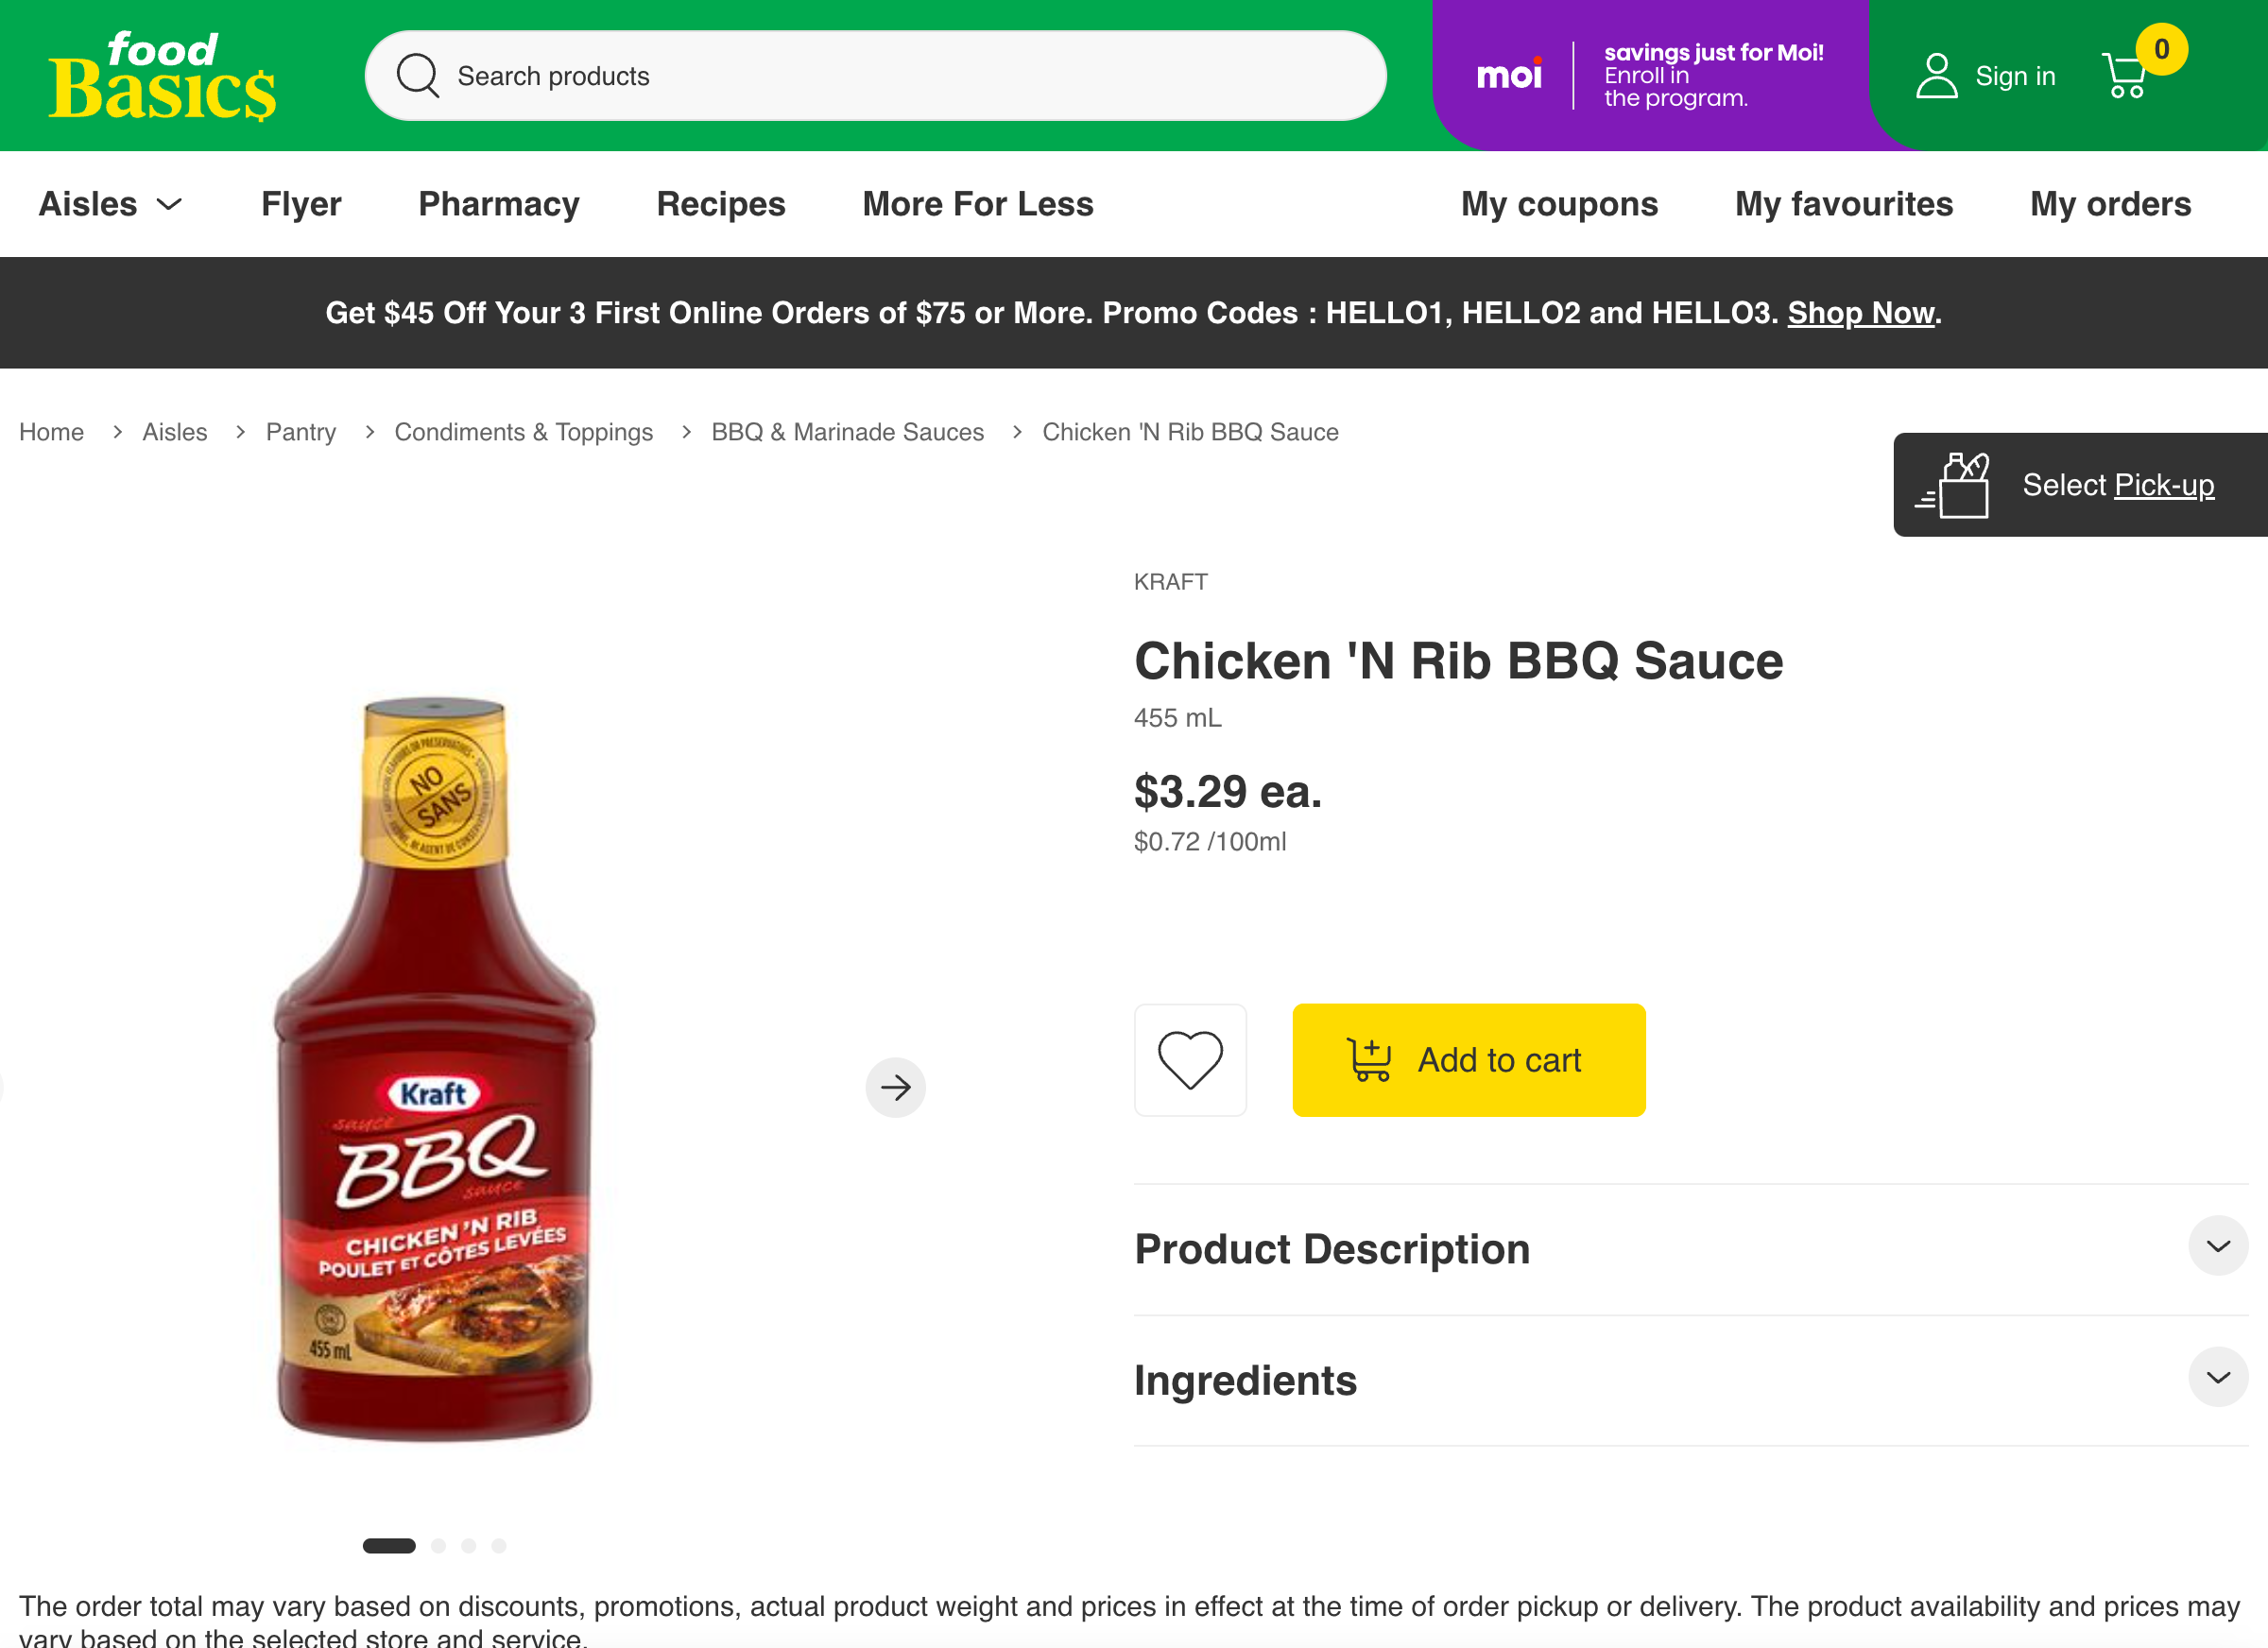

In [40]:
# save_screencapture( get_cheapest(scrape_search("Kraft BBQ Sauce"))['url'] , f'./screenshots/random_product.png')

# # Display the screenshot
# display(Image(filename='./screenshots/random_product.png', width=500))

## Connceting in bulk

get items
[{'title': 'Halal Chicken Flavoured Bouillon Cubes', 'weight': '80 g', 'price': '$1.29', 'price_per_unit': '$1.61 /100g', 'url': 'https://www.foodbasics.ca/aisles/pantry/herbs-spices-sauces/stock-gravy/halal-chicken-flavoured-bouillon-cubes/p/068400804895'}, {'title': 'Chicken Bouillon Cubes', 'weight': '69 g', 'price': '$2.79', 'price_per_unit': '$4.04 /100g', 'url': 'https://www.foodbasics.ca/aisles/pantry/herbs-spices-sauces/stock-gravy/chicken-bouillon-cubes/p/055220000019'}, {'title': 'Instant Chicken Stock Mix', 'weight': '150 g', 'price': '$3.49', 'price_per_unit': '$2.33 /100g', 'url': 'https://www.foodbasics.ca/aisles/pantry/herbs-spices-sauces/stock-gravy/instant-chicken-stock-mix/p/066345700159'}, {'title': 'Chicken Concentrated Liquid Stock, Bovril', 'weight': '250 mL', 'price': '$4.49', 'price_per_unit': '$1.80 /100ml', 'url': 'https://www.foodbasics.ca/aisles/pantry/herbs-spices-sauces/stock-gravy/chicken-concentrated-liquid-stock/p/061400000571'}]
get cheapest


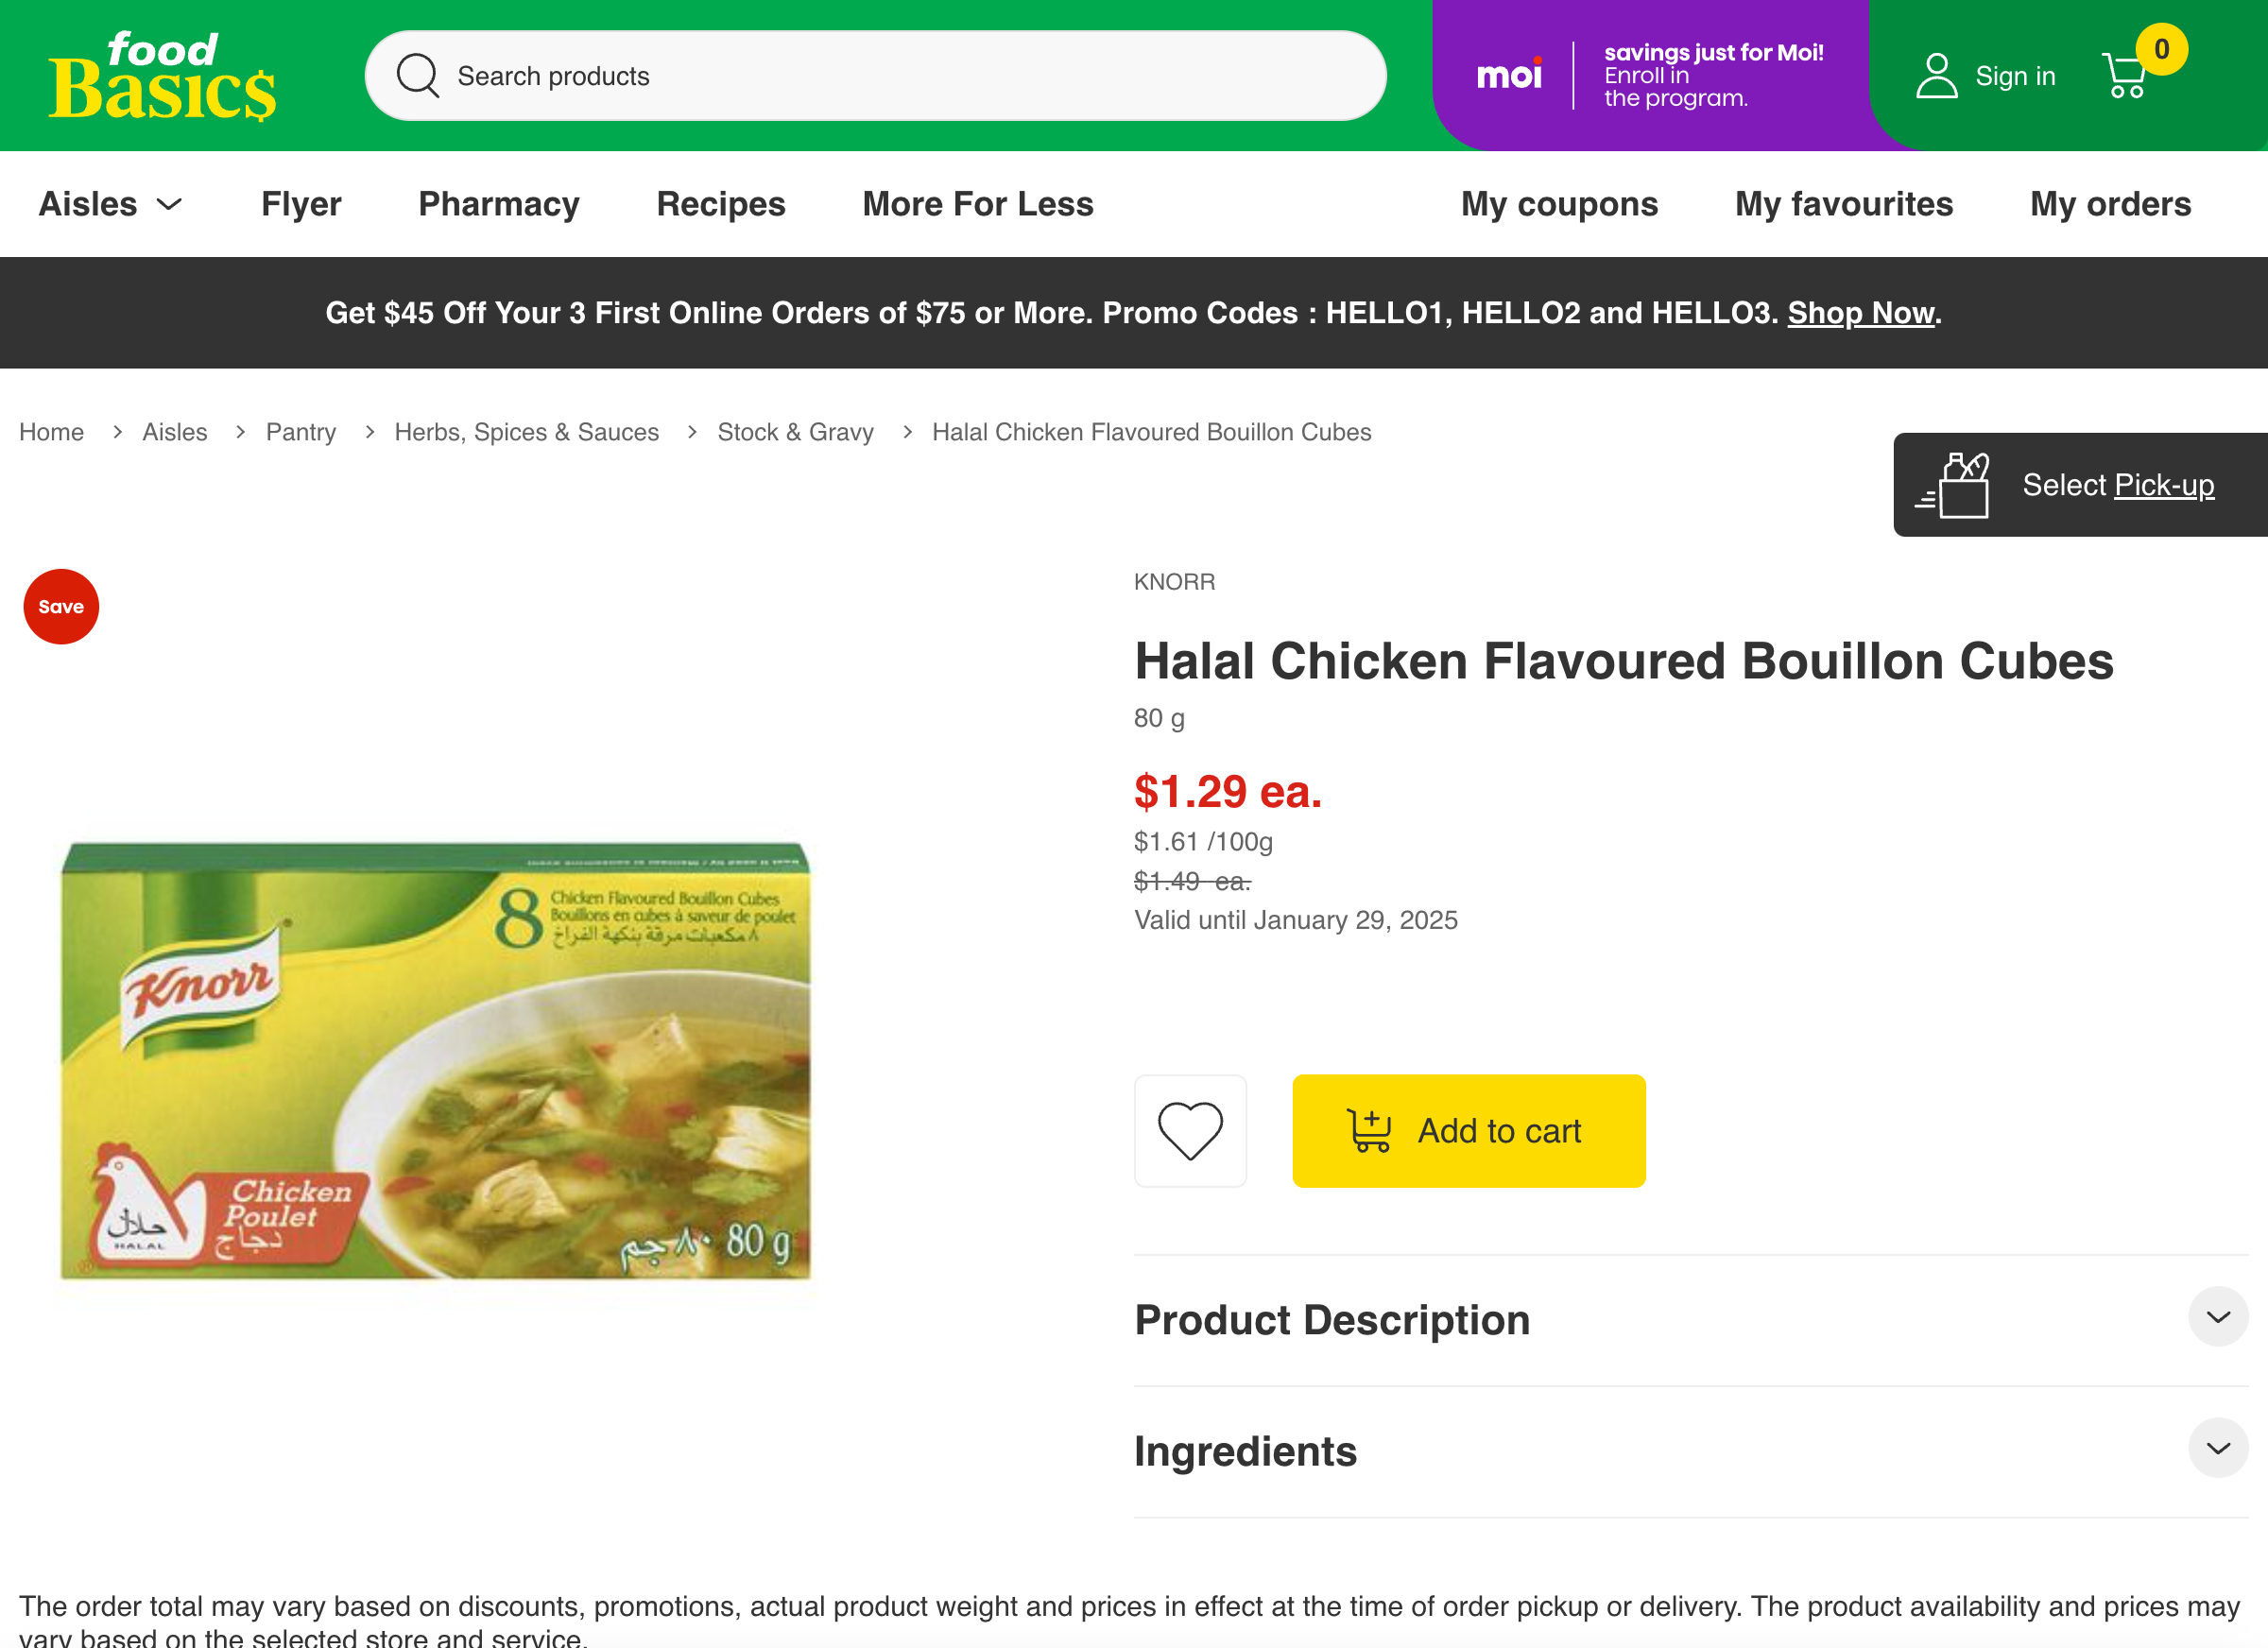

In [ ]:
from datetime import datetime

def auto_search(product_name):
    print(f"get items for {product_name}")
    items = scrape_search(product_name)
    print(items)
    print("get cheapest")
    target_item = get_cheapest(items)
    print(target_item)
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    save_filename = f'./screenshots/{product_name}_{timestamp}.png'
    save_screencapture(target_item['url'], save_filename)
    display(Image(filename=save_filename, width=500))

auto_search(df_mapping.iloc[2]['product_name'])

TODO
- [ ] Store scraped data (list of products in search results)
- [ ] Store target product details
- [ ] Add target product scrape data to db (or somewhere for report generation for now)